In [105]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pandas as pd
from skimage.metrics import structural_similarity, mean_squared_error

Домашнее задание

In [106]:
image_hw = cv2.imread('rs_ph.jpg')
image_gray_hw = cv2.cvtColor(image_hw, cv2.COLOR_BGR2GRAY) 

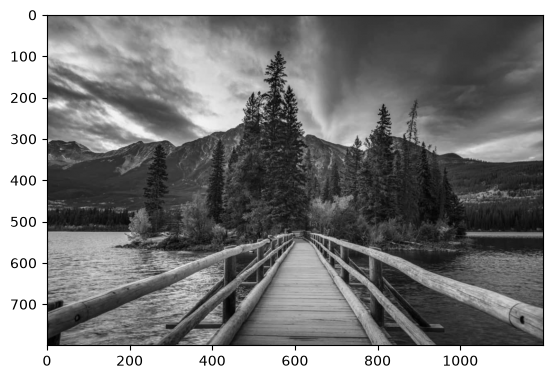

In [107]:
plt.imshow(image_gray_hw, cmap="gray")

In [108]:
# Задание 1
def add_gaussian_noise(img, mean=0, stddev=25):
    """Гауссов шум"""
    noise = np.zeros(img.shape, dtype=np.int16)
    cv2.randn(noise, mean, stddev)
    noisy = img.astype(np.int16) + noise
    return np.clip(noisy, 0, 255).astype(np.uint8)

In [109]:
def add_salt_pepper_noise(img, amount=0.05, salt_vs_pepper=0.5):
    """Импульсный шум"""
    noisy = img.copy()
    n = img.size
    n_salt = int(amount * salt_vs_pepper * n)
    n_pepper = int(amount * (1 - salt_vs_pepper) * n)

    coords = (np.random.randint(0, img.shape[0], n_salt),
              np.random.randint(0, img.shape[1], n_salt))
    noisy[coords] = 255

    coords = (np.random.randint(0, img.shape[0], n_pepper),
              np.random.randint(0, img.shape[1], n_pepper))
    noisy[coords] = 0
    return noisy

In [110]:
np.random.seed(42)

img_gauss_noisy = add_gaussian_noise(image_gray_hw, mean=0, stddev=25)
img_sp_noisy    = add_salt_pepper_noise(image_gray_hw, amount=0.05, salt_vs_pepper=0.5)

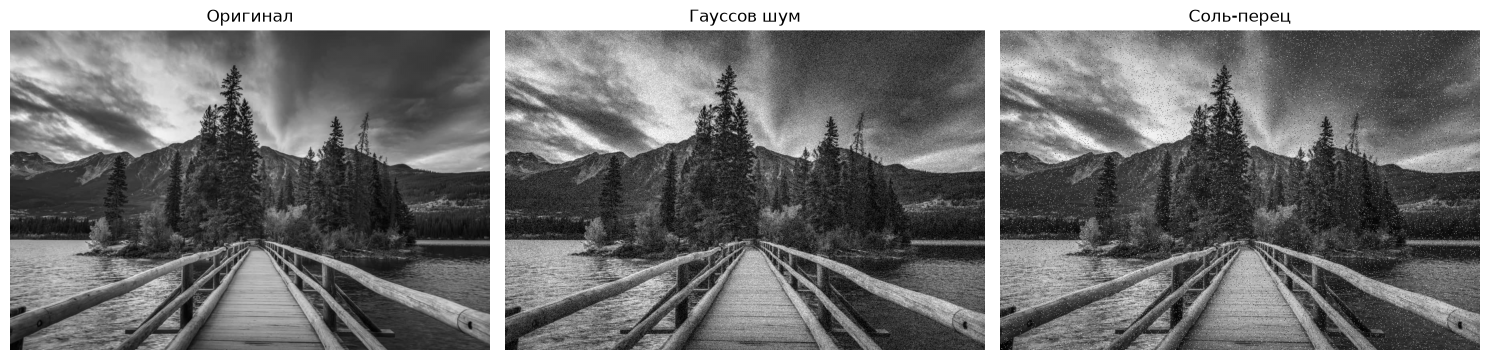

In [111]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(image_gray_hw, cmap="gray");    axes[0].set_title("Оригинал")
axes[1].imshow(img_gauss_noisy, cmap="gray");  axes[1].set_title("Гауссов шум")
axes[2].imshow(img_sp_noisy, cmap="gray");     axes[2].set_title("Соль-перец")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

In [112]:
mse_gauss_noisy  = mean_squared_error(image_gray_hw, img_gauss_noisy)
ssim_gauss_noisy = structural_similarity(image_gray_hw, img_gauss_noisy, full=True)[0]

mse_sp_noisy  = mean_squared_error(image_gray_hw, img_sp_noisy)
ssim_sp_noisy = structural_similarity(image_gray_hw, img_sp_noisy, full=True)[0]

print("Гауссов шум  - MSE: %.2f  SSIM: %.4f" % (mse_gauss_noisy, ssim_gauss_noisy))
print("Соль-перец   - MSE: %.2f  SSIM: %.4f" % (mse_sp_noisy,    ssim_sp_noisy))

Гауссов шум  - MSE: 599.20  SSIM: 0.3183
Соль-перец   - MSE: 972.60  SSIM: 0.3620


In [113]:
# Задание 2
def apply_median(img, ksize=3):
    return cv2.medianBlur(img, ksize)

def apply_gaussian(img, ksize=(5, 5), sigma=0):
    return cv2.GaussianBlur(img, ksize, sigma)

def apply_bilateral(img, d=9, sigma_color=75, sigma_space=75):
    return cv2.bilateralFilter(img, d, sigma_color, sigma_space)

def apply_nlm(img, h=10, template_window=7, search_window=21):
    return cv2.fastNlMeansDenoising(img, None, h, template_window, search_window)

def evaluate(img_clean, img_denoised):
    mse  = mean_squared_error(img_clean, img_denoised)
    ssim = structural_similarity(img_clean, img_denoised, full=True)[0]
    return mse, ssim

In [114]:
param_grids = {
    "median":    [dict(ksize=k) for k in (3, 5, 7, 9)],
    "gaussian":  [dict(ksize=(k, k), sigma=s)
                  for k in (3, 5, 7, 9) for s in (0, 1, 2, 3)],
    "bilateral": [dict(d=d, sigma_color=sc, sigma_space=ss)
                  for d in (5, 9) for sc in (30, 75, 150) for ss in (30, 75, 150)],
    "nlm":       [dict(h=h, template_window=tw, search_window=sw)
                  for h in (5, 10, 15, 20, 25)
                  for tw in (5, 7) for sw in (15, 21)],
}

filters = {
    "median":    apply_median,
    "gaussian":  apply_gaussian,
    "bilateral": apply_bilateral,
    "nlm":       apply_nlm,
}

In [117]:
def run_benchmark(noisy_img, label):
    results = []   
    for fname, fn in filters.items():
        for params in param_grids[fname]:
            try:
                denoised = fn(noisy_img, **params)
            except cv2.error:
                continue
            mse, ssim = evaluate(image_gray_hw, denoised)
            results.append((fname, params, mse, ssim, denoised))

    print(f"\n==================== Шум: {label} ====================")
    
    df = pd.DataFrame(results, columns=['Фильтр', 'Параметры', 'MSE', 'SSIM', 'Img'])
    df = df.drop(columns=['Img'])
    df = df.sort_values(by='MSE').reset_index(drop=True)
    
    print("ТОП-10 лучших результатов по MSE:")
    display(df.head(10)) 
    
    best_mse  = min(results, key=lambda r: r[2])
    best_ssim = max(results, key=lambda r: r[3])
    print("\nЛучший по MSE :", best_mse[0],  best_mse[1],
          f"-> MSE={best_mse[2]:.2f}, SSIM={best_mse[3]:.4f}")
    print("Лучший по SSIM:", best_ssim[0], best_ssim[1],
          f"-> MSE={best_ssim[2]:.2f}, SSIM={best_ssim[3]:.4f}")
    return results, best_mse, best_ssim

In [118]:
results_gauss, best_gauss_mse, best_gauss_ssim = run_benchmark(img_gauss_noisy, "Гауссов")
results_sp,    best_sp_mse,    best_sp_ssim    = run_benchmark(img_sp_noisy,    "Соль-перец")


==================== Шум: Гауссов ====================
ТОП-10 лучших результатов по MSE:


,Фильтр,Параметры,MSE,SSIM
0,nlm,"{'h': 25, 'template_window': 5, 'search_window...",83.082182,0.763989
1,nlm,"{'h': 25, 'template_window': 5, 'search_window...",87.749064,0.764587
2,nlm,"{'h': 25, 'template_window': 7, 'search_window...",89.255596,0.761535
3,nlm,"{'h': 20, 'template_window': 5, 'search_window...",92.311221,0.742990
4,bilateral,"{'d': 5, 'sigma_color': 75, 'sigma_space': 30}",94.512745,0.706032
5,bilateral,"{'d': 5, 'sigma_color': 75, 'sigma_space': 75}",94.517568,0.706032
6,bilateral,"{'d': 5, 'sigma_color': 75, 'sigma_space': 150}",94.517636,0.706033
7,nlm,"{'h': 20, 'template_window': 7, 'search_window...",95.942059,0.759840
8,nlm,"{'h': 25, 'template_window': 7, 'search_window...",98.166947,0.754144
9,nlm,"{'h': 20, 'template_window': 5, 'search_window...",102.356244,0.715780



Лучший по MSE : nlm {'h': 25, 'template_window': 5, 'search_window': 15} -> MSE=83.08, SSIM=0.7640
Лучший по SSIM: nlm {'h': 25, 'template_window': 5, 'search_window': 21} -> MSE=87.75, SSIM=0.7646

==================== Шум: Соль-перец ====================
ТОП-10 лучших результатов по MSE:


,Фильтр,Параметры,MSE,SSIM
0,median,{'ksize': 3},38.858305,0.935364
1,median,{'ksize': 5},91.749565,0.835611
2,bilateral,"{'d': 5, 'sigma_color': 150, 'sigma_space': 150}",119.813676,0.704863
3,bilateral,"{'d': 5, 'sigma_color': 150, 'sigma_space': 75}",119.827853,0.704817
4,bilateral,"{'d': 5, 'sigma_color': 150, 'sigma_space': 30}",119.843120,0.704796
5,median,{'ksize': 7},131.966952,0.759388
6,gaussian,"{'ksize': (5, 5), 'sigma': 0}",145.977315,0.670988
7,gaussian,"{'ksize': (7, 7), 'sigma': 1}",146.371065,0.666241
8,gaussian,"{'ksize': (9, 9), 'sigma': 1}",146.371065,0.666241
9,gaussian,"{'ksize': (7, 7), 'sigma': 0}",147.387433,0.710436



Лучший по MSE : median {'ksize': 3} -> MSE=38.86, SSIM=0.9354
Лучший по SSIM: median {'ksize': 3} -> MSE=38.86, SSIM=0.9354


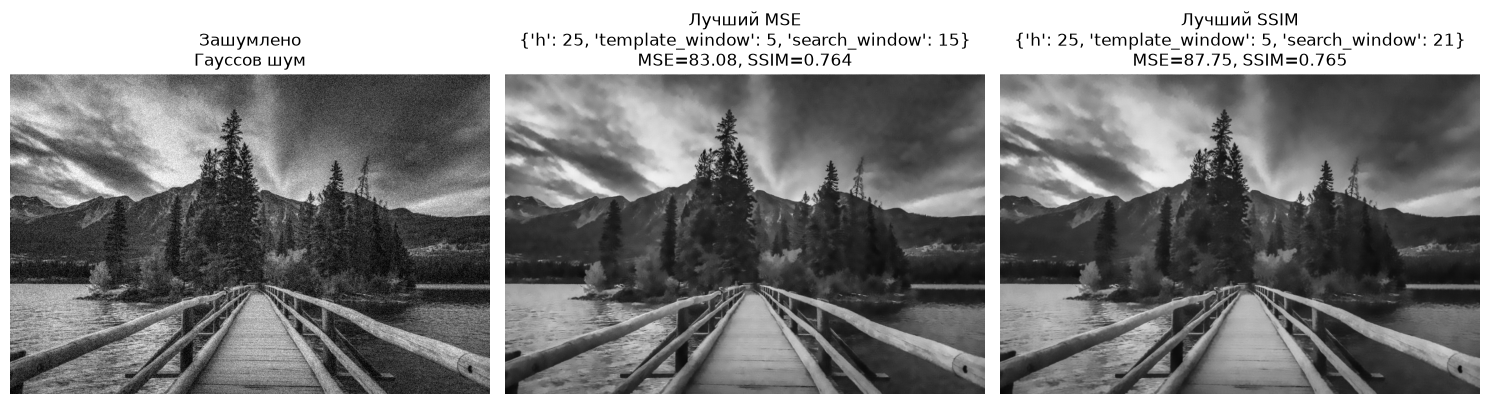

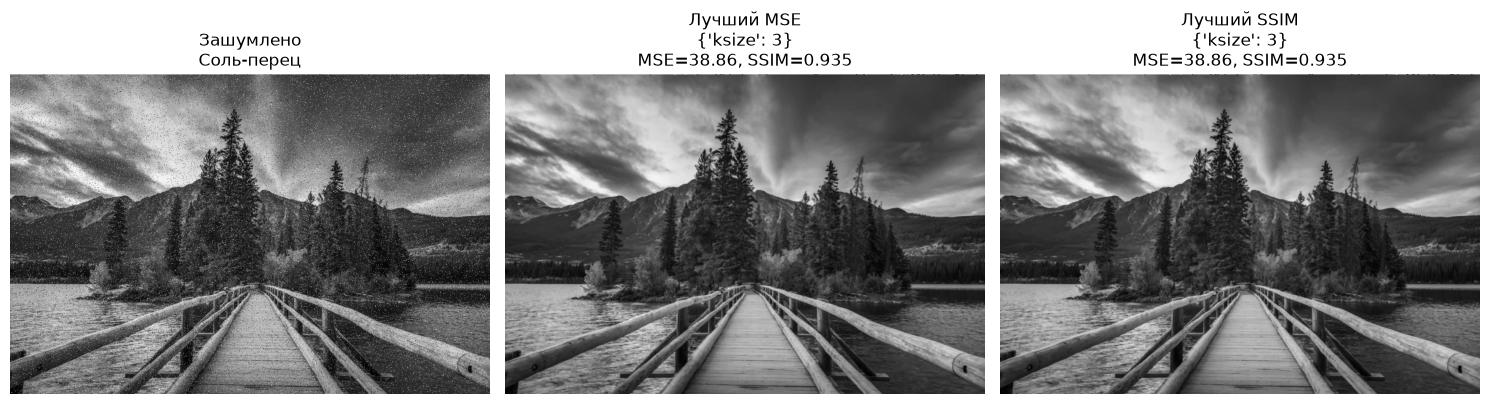

In [119]:
def show_best(noisy, best_mse, best_ssim, title):
    _, p_mse,  mse_mse,  ssim_mse,  img_mse  = best_mse
    _, p_ssim, mse_ssim, ssim_ssim, img_ssim = best_ssim

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(noisy, cmap="gray")
    axes[0].set_title(f"Зашумлено\n{title}"); axes[0].axis("off")

    axes[1].imshow(img_mse, cmap="gray")
    axes[1].set_title(f"Лучший MSE\n{p_mse}\nMSE={mse_mse:.2f}, SSIM={ssim_mse:.3f}")
    axes[1].axis("off")

    axes[2].imshow(img_ssim, cmap="gray")
    axes[2].set_title(f"Лучший SSIM\n{p_ssim}\nMSE={mse_ssim:.2f}, SSIM={ssim_ssim:.3f}")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()


show_best(img_gauss_noisy, best_gauss_mse, best_gauss_ssim, "Гауссов шум")
show_best(img_sp_noisy,    best_sp_mse,    best_sp_ssim,    "Соль-перец")

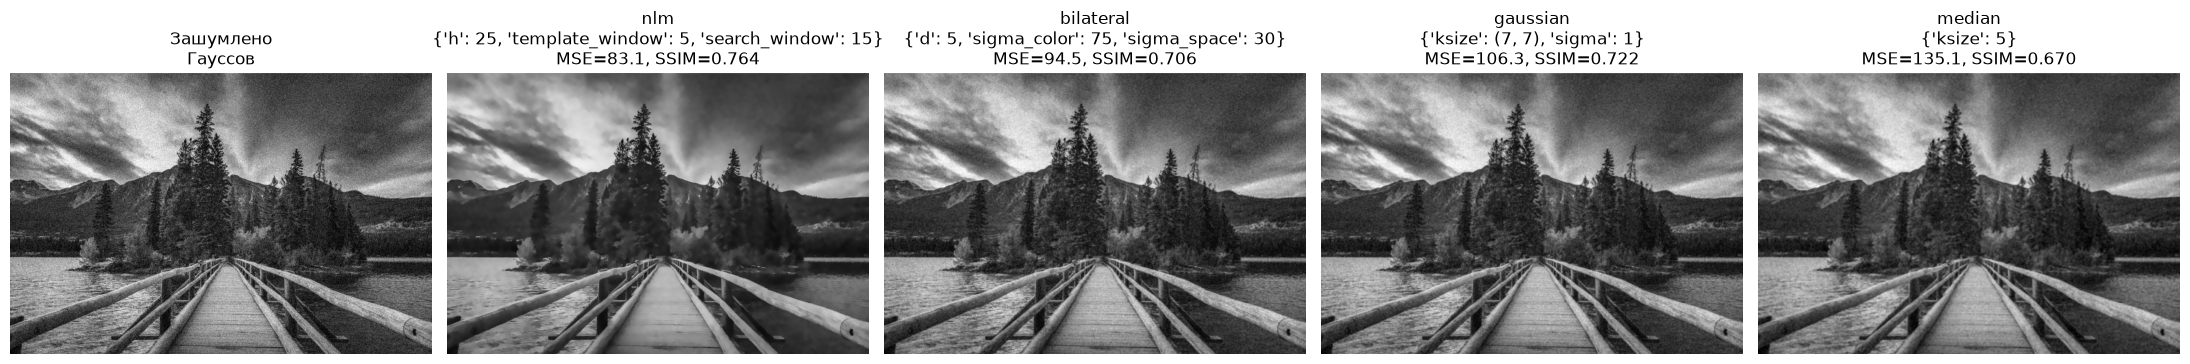

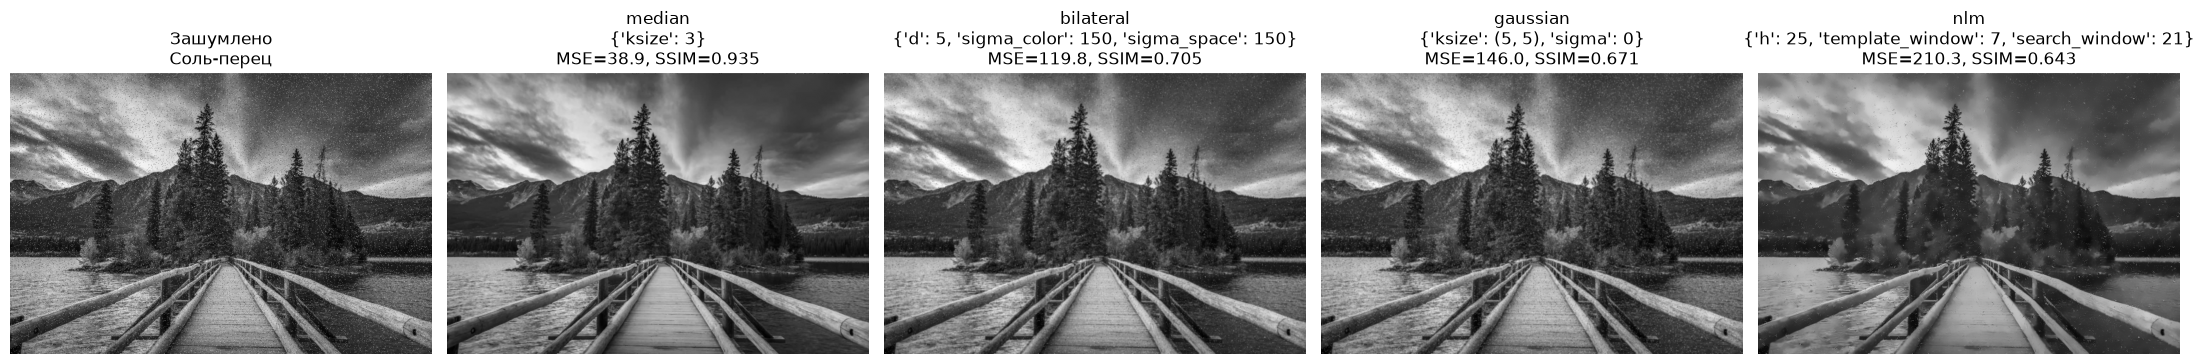

In [120]:
def top_per_filter(results):
    out = {}
    for fname, params, mse, ssim, img in sorted(results, key=lambda r: r[2]):
        if fname not in out:
            out[fname] = (params, mse, ssim, img)
    return out


for label, results, noisy in [("Гауссов", results_gauss, img_gauss_noisy),
                              ("Соль-перец", results_sp, img_sp_noisy)]:
    top = top_per_filter(results)
    fig, axes = plt.subplots(1, 5, figsize=(22, 5))

    axes[0].imshow(noisy, cmap="gray")
    axes[0].set_title(f"Зашумлено\n{label}")
    axes[0].axis("off")

    for i, (fname, (params, mse, ssim, img)) in enumerate(top.items(), start=1):
        axes[i].imshow(img, cmap="gray")
        axes[i].set_title(f"{fname}\n{params}\nMSE={mse:.1f}, SSIM={ssim:.3f}")
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

In [121]:
# Задание 3
print("=" * 60)
print("ВЫВОДЫ")
print("=" * 60)

print("\n[Гауссов шум]")
print("  Лучший MSE  :", best_gauss_mse[0],  best_gauss_mse[1],
      f"-> MSE={best_gauss_mse[2]:.2f}, SSIM={best_gauss_mse[3]:.4f}")
print("  Лучший SSIM :", best_gauss_ssim[0], best_gauss_ssim[1],
      f"-> MSE={best_gauss_ssim[2]:.2f}, SSIM={best_gauss_ssim[3]:.4f}")

print("\n[Соль-перец]")
print("  Лучший MSE  :", best_sp_mse[0],  best_sp_mse[1],
      f"-> MSE={best_sp_mse[2]:.2f}, SSIM={best_sp_mse[3]:.4f}")
print("  Лучший SSIM :", best_sp_ssim[0], best_sp_ssim[1],
      f"-> MSE={best_sp_ssim[2]:.2f}, SSIM={best_sp_ssim[3]:.4f}")

ВЫВОДЫ

[Гауссов шум]
  Лучший MSE  : nlm {'h': 25, 'template_window': 5, 'search_window': 15} -> MSE=83.08, SSIM=0.7640
  Лучший SSIM : nlm {'h': 25, 'template_window': 5, 'search_window': 21} -> MSE=87.75, SSIM=0.7646

[Соль-перец]
  Лучший MSE  : median {'ksize': 3} -> MSE=38.86, SSIM=0.9354
  Лучший SSIM : median {'ksize': 3} -> MSE=38.86, SSIM=0.9354
